### Autor: Agnieszka Grala
Zadania:

$\begin{array}{ccc}
1&2&3&4&5&6&7&8\\
X&X&X&X&X&X&X&X
\end{array}$

# Assignment 3

**Submission deadlines:**

  - Tuesday groups: 22.04.2025
  - Friday groups: 18.04.2025

**Points:** Aim to get 10 points + 4 extra

## Submission instructions
The class is held on-site in lab rooms. Please prepare you notebook on your computer or anywhere in the cloud (try using DeepNote or Google Colab).

Make sure you know all the questions and answers, and that the notebook contains results; before presentation do `Runtime -> Restart and run all`

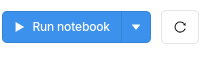

We provide starter code, however you are not required to use it as long as you properly solve the tasks.

# Classify the Oxford Flowers dataset (Weight & Biases) [6p]

In this task, you will train a convolutional neural network to classify images of flowers from the [Oxford Flowers 102 dataset](https://www.robots.ox.ac.uk/~vgg/data/flowers/102/). The dataset consists of 102 flower categories, and each class has between 40 and 258 images. The images have large scale, pose, and light variations. In addition, there are categories that have large variations within the category and several very similar categories.

    
The dataset is available in `torchvision.datasets.Flowers102` class; see [Flowers102.html](https://pytorch.org/vision/main/generated/torchvision.datasets.Flowers102.html). You can use the following code to load the dataset:

```python
import torchvision
import torchvision.transforms as transforms

dataset = torchvision.datasets.Flowers102(root='./data', download=True, transform=transforms.ToTensor())
```

**Hint**: The default split of the dataset is 1020, 1020 and 6149 images for training, validation and test sets respectively.
If you can handle the bigger training dataset, you can experiment by taking up to 80% of the test set for training.


In this task you should run several experiments to classify the images.
In order to track the experiments, you can use the `Weight & Biases` library; see the [documentation](https://docs.wandb.ai/quickstart) for more details.

Implement your code as a single Python script or a Jupyter notebook. Remember to log the experiment configuration, hyperparameters, and results (e.g., training loss, validation loss, accuracy and test loss, accuracy).
For logging, you can use the `wandb.log` function to log the metrics and hyperparameters. You can also log the model architecture, training curves, and other relevant information.

* 1. **[1p]**:
    * Your task is to implement a convolutional neural network from scratch using PyTorch.
    * Your CNN should consist of convolutional layers (Conv2D), pooling layers (MaxPooling2D), activation layers (e.g., ReLU), and fully connected layers (if needed).
    
* 2. **[2p]**:
    * Train your CNN on different training set sized (10%, 20%, 50%, 80%, 100%) and evaluate the performance on the validation set and test set.
        * Report the accuracy and loss on the validation set and test set for each training set size.
    * Train your CNN on the full training set plus 20%, 50% and 80% of the test set and evaluate the performance on the validation set and the remaining test set.
        * Report the accuracy and loss on the validation set and remaining test set for each training set size.
    * Compare the performance of your CNN on the different training set sizes and analyze the results.

* 3. **[1p]**:
    * Implement a baseline AlexNet model using PyTorch.
    * Training AlexNet may take a long time, so try to use GPU acceleration if available.

* 4. **[1p]**:
    * Input normalization: experiment with different input normalization techniques (e.g., mean subtraction, standardization) and analyze their impact on the model's performance.

* 5. **[2p]**:
    * Experiment with different hyperparameters such as learning rate, batch size, number of epochs, and optimizer choice (e.g., SGD, Adam).

* 6. **[2p]**:
    * Modify your CNN architecture to include batch normalization and dropout layers.
    * Experiment with different dropout rates and analyze their impact on the model's performance.

* 7. **[1p]**:
    * Implement data augmentation techniques such as random rotations, shifts, flips, and zooms on the training dataset.
    * Train your CNN with augmented data and compare the performance with the baseline model trained on the original data.

* 8. ***[2p extra points]***:
    * Implement residual connections in your CNN architecture; see the [ResNet paper](https://arxiv.org/abs/1512.03385) for more details.
    * Implement inception modules in your CNN architecture; see the [GoogLeNet paper](https://arxiv.org/abs/1409.4842) for more details.
                

Analyze the results obtained from different experiments.
Discuss the effects of varying training set size, hyperparameters, batch normalization, dropout, and data augmentation on the CNN's performance.
Provide insights into how these factors influence model training, convergence, and generalization.

Use the `Weight & Biases` reports to present your findings in a comprehensive report or presentation; see the [documentation](https://docs.wandb.ai/quickstart) for more details.

**[2p extra]**: present your findings (for each task) in a report format in Weight & Biases.




Link to the project on Weights & Biases: https://wandb.ai/swietygraal-university-of-wroc-aw/Assignment_3 \
Link to the report: https://api.wandb.ai/links/swietygraal-university-of-wroc-aw/z28qf7jt

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch import nn
import torch.nn.functional as F
from torchvision.datasets import Flowers102
from torch.utils.data import DataLoader, Subset, ConcatDataset, random_split
import numpy as np

import wandb
wandb.login()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

### Layers

In [ ]:
class Conv2d(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True):
    super(Conv2d, self).__init__()
    self.in_channels = in_channels
    self.out_channels = out_channels
    self.stride = stride
    self.padding = padding

    if isinstance(kernel_size, int):
      self.kernel_size = (kernel_size, kernel_size)
    else:
      self.kernel_size = kernel_size

    self.weight = nn.Parameter(
      torch.randn(out_channels, in_channels, *self.kernel_size) * (1. / (in_channels * self.kernel_size[0] * self.kernel_size[1]))**0.5
    )
    if bias:
      self.bias = nn.Parameter(torch.zeros(out_channels))
    else:
      self.bias = None

  def forward(self, x):
    batch_size, in_channels, in_h, in_w = x.shape
    kh, kw = self.kernel_size
    sh, sw = (self.stride, self.stride) if isinstance(self.stride, int) else self.stride
    ph, pw = (self.padding, self.padding) if isinstance(self.padding, int) else self.padding

    x = F.pad(x, (pw, pw, ph, ph))

    out_h = (in_h + 2 * ph - kh) // sh + 1
    out_w = (in_w + 2 * pw - kw) // sw + 1

    x_unfold = F.unfold(x, kernel_size=(kh, kw), stride=(sh, sw)).to(x.device)

    weight_flat = self.weight.view(self.out_channels, -1).to(x.device)

    out = weight_flat @ x_unfold
    if self.bias is not None:
      out += self.bias.view(1, -1, 1).to(x.device)

    out = out.view(batch_size, self.out_channels, out_h, out_w)
    return out

In [ ]:
class MaxPool2d(nn.Module):
  def __init__(self, kernel_size, stride=None, padding=0):
    super(MaxPool2d, self).__init__()
    self.kernel_size = (kernel_size, kernel_size) if isinstance(kernel_size, int) else kernel_size
    self.stride = stride if stride is not None else self.kernel_size
    self.stride = (self.stride, self.stride) if isinstance(self.stride, int) else self.stride
    self.padding = (padding, padding) if isinstance(padding, int) else padding

  def forward(self, x):
    B, C, H, W = x.shape
    kh, kw = self.kernel_size
    sh, sw = self.stride
    ph, pw = self.padding

    x = F.pad(x, (pw, pw, ph, ph), mode='constant', value=float('-inf'))

    x_unfold = F.unfold(x, kernel_size=(kh, kw), stride=(sh, sw))
    x_unfold = x_unfold.view(B, C, kh * kw, -1)

    out, _ = x_unfold.max(dim=2)

    out_h = (H + 2 * ph - kh) // sh + 1
    out_w = (W + 2 * pw - kw) // sw + 1

    out = out.view(B, C, out_h, out_w).to(x.device)
    return out

In [ ]:
class ReLU(nn.Module):
  def __init__(self):
    super(ReLU, self).__init__()

  def forward(self, x):
    return torch.clamp(x, min=0)

In [ ]:
class Linear(nn.Module):
  def __init__(self, in_features, out_features, bias=True):
    super(Linear, self).__init__()
    self.in_features = in_features
    self.out_features = out_features

    self.weight = nn.Parameter(torch.randn(out_features, in_features) * (1. / in_features) ** 0.5)
    if bias:
      self.bias = nn.Parameter(torch.zeros(out_features))
    else:
      self.bias = None

  def forward(self, x):
    weight = self.weight.to(x.device)
    out = x @ weight.t()
    if self.bias is not None:
      out += self.bias.to(x.device)
    return out

In [ ]:
class Flatten(nn.Module):
  def __init__(self, start_dim=1):
    super(Flatten, self).__init__()
    self.start_dim = start_dim

  def forward(self, x):
    return x.flatten(start_dim=self.start_dim)

**Problem 6:**

In [ ]:
class BatchNorm1d(nn.Module):
  def __init__(self, num_features, eps=1e-5, momentum=0.1):
    super().__init__()
    self.eps = eps
    self.momentum = momentum
    self.gamma = nn.Parameter(torch.ones(num_features))
    self.beta = nn.Parameter(torch.zeros(num_features))
    self.register_buffer('running_mean', torch.zeros(num_features))
    self.register_buffer('running_var', torch.ones(num_features))

  def forward(self, x):
    if self.training:
      batch_mean = x.mean(dim=0)
      batch_var = x.var(dim=0, unbiased=False)

      self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * batch_mean.detach()
      self.running_var = (1 - self.momentum) * self.running_var + self.momentum * batch_var.detach()

      mean = batch_mean
      var = batch_var
    else:
      mean = self.running_mean.to(x.device)
      var = self.running_var.to(x.device)

    x_hat = (x - mean[None, :]) / torch.sqrt(var[None, :] + self.eps)
    return self.gamma[None, :] * x_hat + self.beta[None, :]

class BatchNorm2d(nn.Module):
  def __init__(self, num_channels, eps=1e-5, momentum=0.1):
    super().__init__()
    self.eps = eps
    self.momentum = momentum
    self.gamma = nn.Parameter(torch.ones(num_channels))
    self.beta = nn.Parameter(torch.zeros(num_channels))
    self.register_buffer('running_mean', torch.zeros(num_channels))
    self.register_buffer('running_var', torch.ones(num_channels))

  def forward(self, x):
    if self.training:
      mean = x.mean(dim=(0, 2, 3))
      var = x.var(dim=(0, 2, 3), unbiased=False)

      self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean.detach()
      self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var.detach()
    else:
      mean = self.running_mean.to(x.device)
      var = self.running_var.to(x.device)

    x_hat = (x - mean[None, :, None, None]) / torch.sqrt(var[None, :, None, None] + self.eps)
    return self.gamma[None, :, None, None] * x_hat + self.beta[None, :, None, None]

In [ ]:
class Dropout(nn.Module):
  def __init__(self, p=0.5):
    super(Dropout, self).__init__()
    self.p = p

  def forward(self, x):
    if not self.training or self.p == 0.0:
      return x
    mask = (torch.rand_like(x) > self.p).float()
    return x * mask / (1 - self.p)

**Problem 8:**

In [ ]:
class ResidualBlock(nn.Module):
  def __init__(self, in_channels, out_channels, downsample=False):
    super().__init__()

    stride = 2 if downsample else 1

    self.block = nn.Sequential(
      Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
      BatchNorm2d(out_channels),
      ReLU(),
      Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
      BatchNorm2d(out_channels)
    )

    self.relu = ReLU()

    if downsample or in_channels != out_channels:
      self.skip_connection = nn.Sequential(
        Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
        BatchNorm2d(out_channels)
      )
    else:
      self.skip_connection = nn.Identity()

  def forward(self, x):
    residual = self.skip_connection(x)
    out = self.block(x)
    out += residual
    return self.relu(out)

In [ ]:
class InceptionBlock(nn.Module):
  def __init__(self, in_channels, out_1x1, red_3x3, out_3x3, red_5x5, out_5x5, out_pool):
    super().__init__()

    self.branch1 = nn.Sequential(
      Conv2d(in_channels, out_1x1, kernel_size=1),
      ReLU()
    )

    self.branch2 = nn.Sequential(
      Conv2d(in_channels, red_3x3, kernel_size=1),
      ReLU(),
      Conv2d(red_3x3, out_3x3, kernel_size=3, padding=1),
      ReLU()
    )

    self.branch3 = nn.Sequential(
      Conv2d(in_channels, red_5x5, kernel_size=1),
      ReLU(),
      Conv2d(red_5x5, out_5x5, kernel_size=3, padding=1),
      ReLU(),
      Conv2d(out_5x5, out_5x5, kernel_size=3, padding=1),
      ReLU()
    )

    self.branch4 = nn.Sequential(
      MaxPool2d(kernel_size=3, stride=1, padding=1),
      Conv2d(in_channels, out_pool, kernel_size=1),
      ReLU()
    )

  def forward(self, x):
    b1 = self.branch1(x)
    b2 = self.branch2(x)
    b3 = self.branch3(x)
    b4 = self.branch4(x)
    return torch.cat([b1, b2, b3, b4], dim=1)

### Optimizers

In [ ]:
class SGD:
  def __init__(self, params, lr=0.01, momentum=0.0):
    self.params = list(params)
    self.lr = lr
    self.momentum = momentum
    self.velocity = {}

  def zero_grad(self):
    for param in self.params:
      if param.grad is not None:
        param.grad.zero_()

  def step(self):
    for param in self.params:
      if param.grad is None:
        continue

      if param not in self.velocity:
        self.velocity[param] = torch.zeros_like(param.data)

      self.velocity[param] = self.momentum * self.velocity[param] + self.lr * param.grad

      param.data -= self.velocity[param]

In [ ]:
class Adam:
  def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
    self.params = list(params)
    self.lr = lr
    self.beta1, self.beta2 = betas
    self.eps = eps

    self.m = {}
    self.v = {}
    self.t = 0

  def zero_grad(self):
    for param in self.params:
      if param.grad is not None:
        param.grad.zero_()

  def step(self):
    self.t += 1
    for param in self.params:
      if param.grad is None:
        continue

      grad = param.grad

      if param not in self.m:
        self.m[param] = torch.zeros_like(param.data)
        self.v[param] = torch.zeros_like(param.data)

      self.m[param] = self.beta1 * self.m[param] + (1 - self.beta1) * grad
      self.v[param] = self.beta2 * self.v[param] + (1 - self.beta2) * grad.pow(2)

      m_hat = self.m[param] / (1 - self.beta1 ** self.t)
      v_hat = self.v[param] / (1 - self.beta2 ** self.t)

      param.data -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

### Utils

In [ ]:
class Model(nn.Module):
  def __init__(self, *layers):
    super(Model, self).__init__()
    self.layers = nn.Sequential(*layers)

  def forward(self, x):
    return self.layers(x)

  def loss(self, output, target):
    return F.cross_entropy(output, target)

In [ ]:
def train(model, dataloader, optimizer, device='cuda', epoch=1):
  model.train()
  total_loss = 0
  correct = 0
  total = 0

  for inputs, targets in dataloader:
    inputs, targets = inputs.to(device), targets.to(device)

    optimizer.zero_grad()
    outputs = model(inputs)
    #print("Model output mean:", outputs.mean().item(), "std:", outputs.std().item())
    loss = model.loss(outputs, targets)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    pred = outputs.argmax(dim=1)
    correct += (pred == targets).sum().item()
    total += targets.size(0)

  avg_loss = total_loss / len(dataloader)
  accuracy = correct / total
  print(f'Train Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}')
  wandb.log({
    "train_loss": avg_loss,
    "train_accuracy": accuracy,
    "epoch": epoch
  })


In [ ]:
def evaluate(model, dataloader, device='cuda', set_name="Validation"):
  model.eval()
  correct = 0
  total = 0

  with torch.no_grad():
    for inputs, targets in dataloader:
      inputs, targets = inputs.to(device), targets.to(device)
      outputs = model(inputs)
      pred = outputs.argmax(dim=1)
      correct += (pred == targets).sum().item()
      total += targets.size(0)

  accuracy = correct / total
  print(f'{set_name} Accuracy: {accuracy:.4f}')
  wandb.log({
    f"{set_name}_accuracy": accuracy,
  })

**Problem 2:**

In [ ]:
def get_fraction(dataset, fraction, seed=42):
  np.random.seed(seed)
  total = len(dataset)
  indices = np.random.permutation(total)[:int(total * fraction)]
  return Subset(dataset, indices)

def split_test_for_training(test_dataset, used_fraction, seed=42):
  np.random.seed(seed)
  total = len(test_dataset)
  indices = np.random.permutation(total)
  cutoff = int(total * used_fraction)
  used_indices = indices[:cutoff]
  remaining_indices = indices[cutoff:]

  test_train_part = Subset(test_dataset, used_indices)
  test_remaining  = Subset(test_dataset, remaining_indices)

  return test_train_part, test_remaining

def run_experiment(model, train_set, val_set, test_set, device):
  train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
  val_loader = DataLoader(val_set, batch_size=64)
  test_loader = DataLoader(test_set, batch_size=64)

  model.to(device)
  optimizer = SGD(model.parameters(), lr=0.01, momentum=0.9)

  for epoch in range(10):
    train(model, train_loader, optimizer, device)
    evaluate(model, val_loader, device=device)

  evaluate(model, test_loader, device=device, set_name="Test")

**Problem 4:**

In [ ]:
def compute_dataset_stats(dataset):
  loader = DataLoader(dataset, batch_size=64, shuffle=False)
  mean = 0.
  std = 0.
  total = 0
  for images, _ in loader:
    batch_size = images.size(0)
    images = images.view(batch_size, 3, -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total += batch_size

  mean /= total
  std /= total
  return mean.tolist(), std.tolist()

### Model

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Problem 7
'''
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=30),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
'''

train_dataset = Flowers102(root='./data', split='train', download=True, transform=transform)
val_dataset   = Flowers102(root='./data', split='val',   download=True, transform=transform)
test_dataset  = Flowers102(root='./data', split='test',  download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64)
test_loader  = DataLoader(test_dataset, batch_size=64)

# Problem 4
'''
mean, std = compute_dataset_stats(train_dataset)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_dataset = Flowers102(root='./data', split='train', download=True, transform=transform)
val_dataset   = Flowers102(root='./data', split='val',   download=True, transform=transform)
test_dataset  = Flowers102(root='./data', split='test',  download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64)
test_loader  = DataLoader(test_dataset, batch_size=64)
'''

"\nmean, std = compute_dataset_stats(train_dataset)\n\ntransform = transforms.Compose([\n    transforms.Resize((224, 224)),\n    transforms.ToTensor(),\n    transforms.Normalize(mean=mean, std=std)\n])\n\ntrain_dataset = Flowers102(root='./data', split='train', download=True, transform=transform)\nval_dataset   = Flowers102(root='./data', split='val',   download=True, transform=transform)\ntest_dataset  = Flowers102(root='./data', split='test',  download=True, transform=transform)\n\ntrain_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)\nval_loader   = DataLoader(val_dataset, batch_size=64)\ntest_loader  = DataLoader(test_dataset, batch_size=64)\n"

In [ ]:
wandb.init(
    project="Assignment_3",
    name="exp_inception_modules",
    config={
        "input_size": (3, 224, 224),
        "epochs": 10,
        "batch_size": 64,
        "optimizer": "SGD",
        "momentum": 0.9,
        "learning_rate": 0.01,
        "loss_function": "cross_entropy",
        "model_depth": "2 conv + 2 linear"
    }
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = Model(
  Conv2d(3, 16, kernel_size=3),
  #BatchNorm2d(16),
  ReLU(),
  MaxPool2d(kernel_size=2),

  Conv2d(16, 32, kernel_size=3),
  #BatchNorm2d(32),
  ReLU(),
  MaxPool2d(kernel_size=2),

  Flatten(),
  Linear(32 * 54 * 54, 256),
  #BatchNorm1d(256),
  ReLU(),
  #Dropout(0.6),
  Linear(256, 102)
)

# Problem 8
'''
model = Model(
  Conv2d(3, 16, kernel_size=3),
  ReLU(),
  MaxPool2d(kernel_size=2),


  ResidualBlock(16, 16),
  ResidualBlock(16, 32, downsample=True),
  MaxPool2d(kernel_size=2),

  Flatten(),
  Linear(32 * 28 * 28, 256),
  ReLU(),
  Linear(256, 102)
)

model = Model(
  Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
  ReLU(),
  MaxPool2d(kernel_size=3, stride=2, padding=1),

  InceptionBlock(64, 32, 48, 64, 8, 16, 16),
  MaxPool2d(kernel_size=3, stride=2, padding=1),

  Flatten(),
  Linear(128 * 28 * 28, 256),
  ReLU(),
  Linear(256, 102)
)
'''

model.to(device)

for epoch in range(10):
  print(f"Epoch {epoch+1}")
  train(model, train_loader, SGD(model.parameters(), lr=0.01, momentum=0.9), epoch=epoch+1)
  evaluate(model, val_loader)

evaluate(model, test_loader, set_name="Test")

wandb.finish()

Epoch 1
Train Loss: 4.6843 | Accuracy: 0.0098
Validation Accuracy: 0.0225
Epoch 2
Train Loss: 4.5620 | Accuracy: 0.0245
Validation Accuracy: 0.0157
Epoch 3
Train Loss: 4.4416 | Accuracy: 0.0284
Validation Accuracy: 0.0412
Epoch 4
Train Loss: 4.2252 | Accuracy: 0.0529
Validation Accuracy: 0.0500
Epoch 5
Train Loss: 3.9801 | Accuracy: 0.0755
Validation Accuracy: 0.0598
Epoch 6
Train Loss: 3.7231 | Accuracy: 0.1333
Validation Accuracy: 0.0853
Epoch 7
Train Loss: 3.4328 | Accuracy: 0.1696
Validation Accuracy: 0.1108
Epoch 8
Train Loss: 3.1784 | Accuracy: 0.2176
Validation Accuracy: 0.1039
Epoch 9
Train Loss: 2.9182 | Accuracy: 0.2755
Validation Accuracy: 0.1206
Epoch 10
Train Loss: 2.5517 | Accuracy: 0.3569
Validation Accuracy: 0.1245
Test Accuracy: 0.1008


Test_accuracy,▁
Validation_accuracy,▁▁▃▃▄▅▇▇██
epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▁▁▂▂▃▄▅▆█
train_loss,██▇▆▆▅▄▃▂▁
Test_accuracy,0.10083
Validation_accuracy,0.12451
epoch,10
train_accuracy,0.35686
train_loss,2.55166


### Problem 2

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for train_frac in [0.1, 0.2, 0.5, 0.8, 1.0]:
  wandb.init(
    project="Assignment_3",
    name=f"exp_train_size_{train_frac}",
    config={
        "input_size": (3, 224, 224),
        "epochs": 10,
        "batch_size": 64,
        "optimizer": "SGD",
        "momentum": 0.9,
        "learning_rate": 0.01,
        "loss_function": "cross_entropy",
        "model_depth": "2 conv + 2 linear"
    }
  )

  model = Model(
    Conv2d(3, 16, kernel_size=3),
    ReLU(),
    MaxPool2d(kernel_size=2),
    Conv2d(16, 32, kernel_size=3),
    ReLU(),
    MaxPool2d(kernel_size=2),
    Flatten(),
    Linear(32 * 54 * 54, 256),
    ReLU(),
    Linear(256, 102)
  )

  subset = get_fraction(train_dataset, train_frac)
  run_experiment(model, subset, val_dataset, test_dataset, device)
  wandb.finish()

for test_frac in [0.2, 0.5, 0.8]:
  wandb.init(
    project="Assignment_3",
    name=f"exp_train_size_{1.0 + test_frac}",
    config={
        "input_size": (3, 224, 224),
        "epochs": 10,
        "batch_size": 64,
        "optimizer": "SGD",
        "momentum": 0.9,
        "learning_rate": 0.01,
        "loss_function": "cross_entropy",
        "model_depth": "2 conv + 2 linear"
    }
  )

  model = Model(
    Conv2d(3, 16, kernel_size=3),
    ReLU(),
    MaxPool2d(kernel_size=2),
    Conv2d(16, 32, kernel_size=3),
    ReLU(),
    MaxPool2d(kernel_size=2),
    Flatten(),
    Linear(32 * 54 * 54, 256),
    ReLU(),
    Linear(256, 102)
  )

  test_train_part, test_remaining = split_test_for_training(test_dataset, test_frac)
  extended_train = ConcatDataset([train_dataset, test_train_part])
  run_experiment(model, extended_train, val_dataset, test_remaining, device)
  wandb.finish()

Train Loss: 4.6454 | Accuracy: 0.0000
Validation Accuracy: 0.0176
Train Loss: 4.4052 | Accuracy: 0.0490
Validation Accuracy: 0.0127
Train Loss: 4.1211 | Accuracy: 0.0490
Validation Accuracy: 0.0167
Train Loss: 4.0001 | Accuracy: 0.0882
Validation Accuracy: 0.0245
Train Loss: 3.5686 | Accuracy: 0.1373
Validation Accuracy: 0.0255
Train Loss: 2.9259 | Accuracy: 0.4902
Validation Accuracy: 0.0225
Train Loss: 2.3209 | Accuracy: 0.5294
Validation Accuracy: 0.0284
Train Loss: 1.7443 | Accuracy: 0.5980
Validation Accuracy: 0.0127
Train Loss: 3.2487 | Accuracy: 0.4706
Validation Accuracy: 0.0353
Train Loss: 2.6462 | Accuracy: 0.6176
Validation Accuracy: 0.0412
Test Accuracy: 0.0294


Test_accuracy,▁
Validation_accuracy,▂▁▂▄▄▃▅▁▇█
epoch,▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▂▂▂▃▇▇█▆█
train_loss,█▇▇▆▅▄▂▁▅▃
Test_accuracy,0.02944
Validation_accuracy,0.04118
epoch,1
train_accuracy,0.61765
train_loss,2.64625


Train Loss: 4.7992 | Accuracy: 0.0098
Validation Accuracy: 0.0098
Train Loss: 4.5451 | Accuracy: 0.0245
Validation Accuracy: 0.0108
Train Loss: 4.3761 | Accuracy: 0.0588
Validation Accuracy: 0.0098
Train Loss: 4.1476 | Accuracy: 0.0539
Validation Accuracy: 0.0216
Train Loss: 3.8159 | Accuracy: 0.1471
Validation Accuracy: 0.0206
Train Loss: 3.3980 | Accuracy: 0.2059
Validation Accuracy: 0.0363
Train Loss: 2.8653 | Accuracy: 0.3088
Validation Accuracy: 0.0373
Train Loss: 2.7516 | Accuracy: 0.3431
Validation Accuracy: 0.0549
Train Loss: 2.7258 | Accuracy: 0.5000
Validation Accuracy: 0.0480
Train Loss: 2.2119 | Accuracy: 0.6078
Validation Accuracy: 0.0461
Test Accuracy: 0.0397


Test_accuracy,▁
Validation_accuracy,▁▁▁▃▃▅▅█▇▇
epoch,▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▁▂▂▃▃▄▅▇█
train_loss,█▇▇▆▅▄▃▂▂▁
Test_accuracy,0.03968
Validation_accuracy,0.04608
epoch,1
train_accuracy,0.60784
train_loss,2.21194


Train Loss: 4.6830 | Accuracy: 0.0098
Validation Accuracy: 0.0127
Train Loss: 4.5104 | Accuracy: 0.0275
Validation Accuracy: 0.0235
Train Loss: 4.3320 | Accuracy: 0.0706
Validation Accuracy: 0.0275
Train Loss: 3.9522 | Accuracy: 0.1157
Validation Accuracy: 0.0441
Train Loss: 3.4393 | Accuracy: 0.2235
Validation Accuracy: 0.0461
Train Loss: 2.8272 | Accuracy: 0.3314
Validation Accuracy: 0.0804
Train Loss: 2.1430 | Accuracy: 0.5235
Validation Accuracy: 0.0814
Train Loss: 1.4719 | Accuracy: 0.6373
Validation Accuracy: 0.0814
Train Loss: 0.9244 | Accuracy: 0.7902
Validation Accuracy: 0.0765
Train Loss: 1.1067 | Accuracy: 0.7922
Validation Accuracy: 0.0873
Test Accuracy: 0.0841


...

Test_accuracy,▁
Validation_accuracy,▁▃▄▅▆▇▇▇▇█
epoch,▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▁▂▃▄▅▆▇██
train_loss,█▇▆▅▅▄▂▂▁▁
Test_accuracy,0.22297
Validation_accuracy,0.23235
epoch,1
train_accuracy,0.91952
train_loss,0.31923


Train Loss: 4.2594 | Accuracy: 0.0662
Validation Accuracy: 0.0696
Train Loss: 3.4555 | Accuracy: 0.1644
Validation Accuracy: 0.1559
Train Loss: 2.8430 | Accuracy: 0.2826
Validation Accuracy: 0.2039
Train Loss: 2.1948 | Accuracy: 0.4353
Validation Accuracy: 0.2294
Train Loss: 1.4096 | Accuracy: 0.6187
Validation Accuracy: 0.2412
Train Loss: 0.6425 | Accuracy: 0.8190
Validation Accuracy: 0.2980
Train Loss: 0.2700 | Accuracy: 0.9267
Validation Accuracy: 0.3157
Train Loss: 0.1189 | Accuracy: 0.9685
Validation Accuracy: 0.2873
Train Loss: 0.0684 | Accuracy: 0.9846
Validation Accuracy: 0.3157
Train Loss: 0.0287 | Accuracy: 0.9934
Validation Accuracy: 0.3284
Test Accuracy: 0.3642


Test_accuracy,▁
Validation_accuracy,▁▃▅▅▆▇█▇██
epoch,▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▂▃▄▅▇▇███
train_loss,█▇▆▅▃▂▁▁▁▁
Test_accuracy,0.36423
Validation_accuracy,0.32843
epoch,1
train_accuracy,0.9934
train_loss,0.02868


Train Loss: 4.0155 | Accuracy: 0.0985
Validation Accuracy: 0.0941
Train Loss: 3.0860 | Accuracy: 0.2426
Validation Accuracy: 0.1784
Train Loss: 2.4968 | Accuracy: 0.3605
Validation Accuracy: 0.2725
Train Loss: 1.9195 | Accuracy: 0.4957
Validation Accuracy: 0.3118
Train Loss: 1.1742 | Accuracy: 0.6811
Validation Accuracy: 0.3039
Train Loss: 0.5081 | Accuracy: 0.8540
Validation Accuracy: 0.3186
Train Loss: 0.2421 | Accuracy: 0.9315
Validation Accuracy: 0.3275
Train Loss: 0.0648 | Accuracy: 0.9847
Validation Accuracy: 0.3461
Train Loss: 0.0268 | Accuracy: 0.9953
Validation Accuracy: 0.3539
Train Loss: 0.0158 | Accuracy: 0.9975
Validation Accuracy: 0.3784
Test Accuracy: 0.4195


Test_accuracy,▁
Validation_accuracy,▁▃▅▆▆▇▇▇▇█
epoch,▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▂▃▄▆▇▇███
train_loss,█▆▅▄▃▂▁▁▁▁
Test_accuracy,0.41951
Validation_accuracy,0.37843
epoch,1
train_accuracy,0.99747
train_loss,0.01576


### Problem 3

In [ ]:
wandb.init(
    project="Assignment_3",
    name="exp_alexnet",
    config={
        "input_size": (3, 224, 224),
        "epochs": 10,
        "batch_size": 64,
        "optimizer": "SGD",
        "momentum": 0.9,
        "learning_rate": 0.01,
        "loss_function": "cross_entropy",
        "model_depth": "5 conv + 3 linear"
    }
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

alexnet = Model(
  Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
  ReLU(),
  MaxPool2d(kernel_size=3, stride=2),

  Conv2d(64, 192, kernel_size=5, padding=2),
  ReLU(),
  MaxPool2d(kernel_size=3, stride=2),

  Conv2d(192, 384, kernel_size=3, padding=1),
  ReLU(),

  Conv2d(384, 256, kernel_size=3, padding=1),
  ReLU(),

  Conv2d(256, 256, kernel_size=3, padding=1),
  ReLU(),
  MaxPool2d(kernel_size=3, stride=2),

  Flatten(),
  Linear(256 * 6 * 6, 4096),
  ReLU(),

  Linear(4096, 4096),
  ReLU(),

  Linear(4096, 102)
)

model.to(device)

for epoch in range(10):
  print(f"Epoch {epoch+1}")
  train(model, train_loader, SGD(model.parameters(), lr=0.01, momentum=0.9), epoch=epoch+1)
  evaluate(model, val_loader)

evaluate(model, test_loader, set_name="Test")

wandb.finish()

Epoch 1
Train Loss: 0.0099 | Accuracy: 0.9980
Validation Accuracy: 0.3892
Epoch 2
Train Loss: 0.0040 | Accuracy: 0.9990
Validation Accuracy: 0.4029
Epoch 3
Train Loss: 0.0020 | Accuracy: 1.0000
Validation Accuracy: 0.4039
Epoch 4
Train Loss: 0.0014 | Accuracy: 1.0000
Validation Accuracy: 0.4157
Epoch 5
Train Loss: 0.0009 | Accuracy: 1.0000
Validation Accuracy: 0.4176
Epoch 6
Train Loss: 0.0008 | Accuracy: 1.0000
Validation Accuracy: 0.4176
Epoch 7
Train Loss: 0.0007 | Accuracy: 1.0000
Validation Accuracy: 0.4176
Epoch 8
Train Loss: 0.0007 | Accuracy: 1.0000
Validation Accuracy: 0.4147
Epoch 9
Train Loss: 0.0006 | Accuracy: 1.0000
Validation Accuracy: 0.4147
Epoch 10
Train Loss: 0.0006 | Accuracy: 1.0000
Validation Accuracy: 0.4157
Test Accuracy: 0.8847


Test_accuracy,▁
Validation_accuracy,▁▄▅████▇▇█
epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▅████████
train_loss,█▄▂▂▁▁▁▁▁▁
Test_accuracy,0.8847
Validation_accuracy,0.41569
epoch,10
train_accuracy,1
train_loss,0.00058
